# **Problem: Portfolio Optimization**

Suppose that an investor wishes to select a set of assets to achieve a good return on the investment while controlling risks of losses. The use of nonlinear models to manage investments began in the 1950s with the pioneering work of Nobel Prize laureate Harry Markowitz, who demonstrated how to reduce the risk of investment by selecting a portfolio of stocks rather than picking individual attractive stocks, and established the trade-off between reward and risk in investment portfolios.

An investment portfolio is defined by the vector $x = (x_1, \ldots, x_n)$, where $x_j$ denotes the proportion of the investment to be invested in asset $j$. Letting $\mu_j$ denote the expected rate of return of asset $j$, the expected rate of return of the portfolio is $\mu^T x$.

Let $\Sigma$ be the matrix of variances and covariances of the assets' returns. The entry $\Sigma_{j,j}$ is the variance of investment $j$. A high variance indicates high volatility or high risk; a low variance indicates stability or low risk. The entry $\Sigma_{i,j}$ is the covariance of investments $i$ and $j$. A positive value of $\Sigma_{i,j}$ indicates assets whose values usually move in the same direction, as often occurs with stocks of companies in the same industry. A negative value indicates assets whose values generally move in opposite directions—a desirable feature in a diversified portfolio. Markowitz defined the risk of the portfolio to be its expected variance $x^T\Sigma x$.

Our optimization problem has two conflicting objectives: to maximize the return $\mu^T x$ and to minimize the risk $x^T\Sigma x$. The relative importance of these objectives will vary depending on the investor's tolerance for risk. We introduce a nonnegative parameter $\alpha$ that reflects the investor's trade-off between risk and return. The objective function in the model will be some combination of the two objectives, parameterized by $\alpha$, leading to the model: \\

> \begin{align*}
& \text{maximize } f(x) = \mu^T x - \alpha x^T \Sigma x
\end{align*}

subject to constraints:
$$ \Sigma x_i  = 1, \quad x \geq 0 $$

The value of $\alpha$ reflects the investor's aversion to risk. A large value indicates a reluctance to take on risk, with an emphasis on the stability of the investment. A low value indicates a high tolerance for risk with an emphasis on the expected return of the investment.

It can be difficult to choose a sensible value for $\alpha$. For this reason, it is common to solve this model for a range of values of this parameter. This can reveal how sensitive the solution is to considerations of risk. The solution of the problem for any value of $\alpha$ is called efficient, indicating that there is no other portfolio that has a larger expected return and a smaller variance.

There are, of course, some limitations to our model. First, we do not generally know the theoretical (joint) distribution of the assets' return and will need to estimate the mean and variance from historical data. Denoting the estimate of $\mu$ by $r$ and the estimate of $\Sigma$ by $V$, the actual problem we solve is:


> \begin{align*}
& \text{maximize } r^T x - \alpha x^T V x \\
& \text{subject to } \sum_{i} x_i = 1 \\
& \hspace{1.75cm} x_i \geq 0 \quad
\end{align*}


Second, investors should be aware that past performance is no indicator of future returns. Finally, we note that the matrix $V$ is dense; that is, it has many nonzero elements. As a result, when the number of assets is large, computations involving $V$ can be expensive, making the optimization problem computationally difficult.To illustrate portfolio optimization, consider an investor who is planning a portfolio
based on four stocks.

**Question 7.2:**
An investor wants to put together a portfolio consisting of the 30 stocks used to
determine the Dow Jones industrial average. Use 25 weekly returns ending on the
last Friday of last month to find the optimal portfolio. Experiment with different
values of the parameter $\alpha$ and plot the corresponding points on the efficient frontier.
You will need access to a nonlinear optimization solver. You may need to use a
modeling language to formulate the problem for input to the solver.



# **Solution:**

In [1]:
# Import libraries needed
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp

In [2]:
# Download historical stock data
stock_data = yf.download("AXP AMGN AAPL BA CAT CSCO CVX GS HD HON IBM INTC JNJ KO JPM MCD MMM MRK MSFT NKE PG TRV UNH CRM VZ V WBA WMT DIS DOW", start="2023-4-03", end="2023-09-30")

# Display the data
stock_data = stock_data["Adj Close"]
stock_data

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-03 00:00:00+00:00,164.691818,233.194778,160.454376,215.389999,222.760040,195.621567,49.925644,159.770309,98.979286,51.164829,...,104.640480,283.867249,119.032837,143.159393,166.984680,482.907501,225.913986,35.335548,31.924883,48.545532
2023-04-04 00:00:00+00:00,164.156631,236.142624,159.259140,213.899994,210.724182,196.328415,49.829483,158.914825,98.790779,50.175373,...,104.602028,283.817810,121.009056,143.848801,163.437408,481.988953,224.592056,35.722961,32.276005,48.068867
2023-04-05 00:00:00+00:00,162.303268,241.713959,158.393814,210.000000,206.925461,194.446793,49.829483,159.704498,99.128120,50.526772,...,107.562386,281.011047,118.279526,144.835052,165.065659,497.604126,225.095169,36.137402,32.519089,48.865490
2023-04-06 00:00:00+00:00,163.195282,241.666275,156.181335,211.369995,202.700302,191.698990,49.300610,157.608093,99.187645,50.545258,...,107.966057,288.186066,117.614273,145.754272,165.996109,501.102386,222.944565,36.158466,32.212986,49.234425
2023-04-10 00:00:00+00:00,160.588654,239.357605,158.452820,210.779999,208.863571,190.643677,49.358303,158.209763,100.021065,51.608692,...,108.235184,286.001923,119.267639,144.547806,167.333618,503.418243,223.378632,36.039398,32.501083,49.139736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-25 00:00:00+00:00,174.991043,259.067596,151.191422,198.779999,268.552795,205.428024,51.815681,161.696915,80.376022,48.525131,...,103.106018,315.174316,89.226303,146.078369,164.627472,502.626129,231.097824,30.913858,19.855669,53.632664
2023-09-26 00:00:00+00:00,170.896530,261.183929,149.109467,195.639999,263.901794,201.595047,51.069645,160.824753,79.423538,47.945751,...,102.667641,309.814514,88.802826,144.779129,164.745163,497.868591,227.423782,30.755375,19.660275,53.445198
2023-09-27 00:00:00+00:00,169.375977,261.125671,147.905716,195.460007,267.025360,201.833984,51.544399,163.930038,79.274712,48.439648,...,101.255104,310.459656,88.064186,142.859329,164.705933,496.174408,227.275223,30.205339,19.557926,53.188660


In [3]:
# Calculate weekly return
weekly_returns = stock_data.resample('W').ffill().pct_change()

# Drop the first row (NaN value)
weekly_returns = weekly_returns[1:]

# Display the weekly returns matrix
print(weekly_returns)

Ticker                         AAPL      AMGN       AXP        BA       CAT  \
Date                                                                          
2023-04-16 00:00:00+00:00  0.003340 -0.013106  0.027640 -0.045702  0.069369   
2023-04-23 00:00:00+00:00 -0.001150 -0.024560  0.003431  0.017054 -0.009900   
2023-04-30 00:00:00+00:00  0.028239 -0.016895 -0.014898  0.007945 -0.006674   
2023-05-07 00:00:00+00:00  0.022925 -0.013389 -0.053861 -0.040816 -0.016956   
2023-05-14 00:00:00+00:00 -0.004386 -0.015136 -0.030920  0.011899 -0.025803   
2023-05-21 00:00:00+00:00  0.015008 -0.031861  0.033935  0.023867  0.025007   
2023-05-28 00:00:00+00:00  0.001541 -0.029049  0.028048 -0.009052 -0.013875   
2023-06-04 00:00:00+00:00  0.031466  0.005255  0.071992  0.047586  0.070019   
2023-06-11 00:00:00+00:00  0.000055  0.003164  0.018747  0.018704  0.037065   
2023-06-18 00:00:00+00:00  0.021883  0.049826  0.002854  0.012333  0.043569   
2023-06-25 00:00:00+00:00  0.009518 -0.011104 -0.024

In [4]:
from prettytable import PrettyTable

# Define the number of stocks (n) and other relevant data
n = len(weekly_returns.columns)
mu = np.mean(weekly_returns, axis=0).to_numpy()

Sigma = weekly_returns.cov().to_numpy()

# Specify the values of alpha (gamma)
gamma_vals = [1, 2, 5, 10, 100]

# Initialize a list to store portfolio allocations
portfolio_allocations = []

# Long only portfolio optimization
w = cp.Variable(n)
gamma = cp.Parameter(nonneg=True)
ret = mu @ w
risk = cp.quad_form(w, Sigma)
constraints = [cp.sum(w) == 1, w >= 0]

for gamma_val in gamma_vals:
    gamma.value = gamma_val
    prob = cp.Problem(cp.Maximize(ret - gamma * risk), constraints)
    prob.solve()

    # Portfolio allocation, mean return, and portfolio variance
    allocation = w.value
    mean_return = ret.value
    portfolio_variance = risk.value

    # Append the results to the list
    portfolio_allocations.append([gamma_val] + list(allocation) + [mean_return, portfolio_variance])

# Print the portfolio allocations
t = PrettyTable()
t.field_names = ["α"] + [f"Stock {i+1}" for i in range(n)] + ["Mean", "Variance"]
for row in portfolio_allocations:
    alpha = row[0]
    formatted_row = [f"{val:.2f}" if val != 0 else " " for val in row[1:-2]]
    formatted_row.append(f"{row[-2]:.3f}")
    formatted_row.append(f"{row[-1]:.1e}")
    t.add_row([alpha] + formatted_row)
print(t)

+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-------+----------+
|  α  | Stock 1 | Stock 2 | Stock 3 | Stock 4 | Stock 5 | Stock 6 | Stock 7 | Stock 8 | Stock 9 | Stock 10 | Stock 11 | Stock 12 | Stock 13 | Stock 14 | Stock 15 | Stock 16 | Stock 17 | Stock 18 | Stock 19 | Stock 20 | Stock 21 | Stock 22 | Stock 23 | Stock 24 | Stock 25 | Stock 26 | Stock 27 | Stock 28 | Stock 29 | Stock 30 |  Mean | Variance |
+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+---------

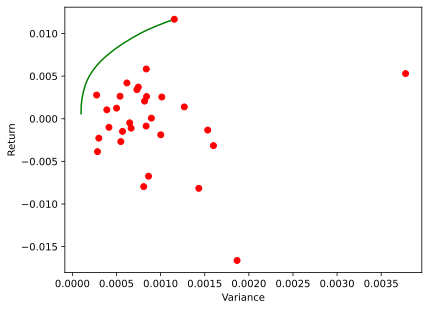

In [5]:
# Compute trade-off curve.
SAMPLES = 100
risk_data = np.zeros(SAMPLES)
ret_data = np.zeros(SAMPLES)

gamma_vals = np.logspace(-2, 3, num=SAMPLES)
for i in range(SAMPLES):
    gamma.value = gamma_vals[i]
    prob.solve()
    risk_data[i] = risk.value
    ret_data[i] = ret.value

# Plot long only trade-off curve.
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(risk_data, ret_data, "g-")
for i in range(n):
    plt.plot((Sigma[i, i]), mu[i], "ro")
plt.xlabel("Variance")
plt.ylabel("Return")
plt.show()